# Obtención geometría a partir de matriz QUBO
## Tutorial Pasqal
QAA to solve a QUBO problem: (este es el que estoy siguiendo en este documento)
https://docs.pasqal.com/pulser/tutorials/qubo/


-Otros tutoriales PasqaL:
QAA to solve a MWIS problem:
https://docs.pasqal.com/pulser/tutorials/mwis/


En este explica además cómo configurar los parámetros para "automatically tuning":
https://docs.pasqal.com/pulser/tutorials/optimization/


In [ ]:
#pip install pulser pulser-simulation
from bloqade.analog import start, cast, load, save
import os
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
from bloqade.analog.atom_arrangement import ListOfLocations, Square
from bloqade.analog import piecewise_linear, cast
from bloqade.analog.atom_arrangement import ListOfLocations, Lieb, Square, Chain, Honeycomb, Kagome, Triangular, Rectangular
import numpy as np
from IPython.display import display, HTML
from bokeh.io import output_notebook
output_notebook()


import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform

c:\Users\javip\Documents\Códigos_TFG\Codigo_tfg\.venv\Lib\site-packages\bloqade\analog\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Loading BokehJS ...

: 

# Formulación QUBO
_Quadratic Unconstrained Binary Optimization_. El objetivo de un problema QUBO es encontrar un vector de variables binarias $x_i \in \{0, 1\}$ que minimice la función de coste escalar $f(x)$: $$f(x) = \sum_{i=1}^{N} Q_{ii} x_i + \sum_{i < j} Q_{ij} x_i x_j$$ $$f(x) = x^T Q x$$
Por convención geométrica, todos los términos de $Q$ se agrupan para que sea una matriz triangular superior.

La formulación QUBO ($x_i \in \{0, 1\}$) es isomorfa al modelo de Ising $z_i \in \{-1, +1\}$ mediante una transformación lineal: $x_i = \frac{1 - z_i}{2}$. 
Resolver la matriz $Q$ equivale algorítmicamente a encontrar el estado fundamental (de mínima energía) del Hamiltoniano del sistema cuántico.

In [64]:
A = 10.0
B = 2
C = 0.1*B

grad_max = 2 # Esto depende de cada grafo

# Parámetros de la simulación (lo vuelvo a definir en la emulación del problema)
#sweep_time = 1.0
#omega_max = 10


In [65]:
Q = np.array(
    [
        [-10.0, 19.7365809, 19.7365809, 5.42015853, 5.42015853],
        [19.7365809, -10.0, 20.67626392, 0.17675796, 0.85604541],
        [19.7365809, 20.67626392, -10.0, 0.85604541, 0.17675796],
        [5.42015853, 0.17675796, 0.85604541, -10.0, 0.32306662],
        [5.42015853, 0.85604541, 0.17675796, 0.32306662, -10.0],
    ]
)

In [66]:
Q = np.array(
    [[-5,   6,   1.5, 0.001, 0.001],
     [6,   -8,   6,   1.5,  0.001],
     [1.5,  6,  -8,   6,    1.5 ],
     [0.001, 1.5, 6,  -8,    6   ],
     [0.001, 0.001,1.5, 6,   -5   ]]
)

print(Q.shape)  # debe ser (5, 5)
assert Q.ndim == 2, "Q debe ser 2D"

(5, 5)


## Q para el grafo $P_3$ (3 puntos en línea)

In [30]:
A=10
B=1
C=0*B
Q = np.array(
    [[-2*B+C, A+2*B],
     [A+2*B, -2*B+C]]
)

# Q grafo $P_4$ (4 puntos en línea)

In [4]:
A=10
B=0.5*A
C=0.8*B

Q = np.array(
    [[-2*B+C, A+2*B, 0],
     [0,      -3*B+C, A+2*B],
     [0,       0,     -2*B+C]]
)

Q_exacta = np.array(
    [[-2*B+C, A+2*B, B],
     [0,      -3*B+C, A+2*B],
     [0,       0,     -2*B+C]]
)

# Q para el grafo en Y

In [68]:
#A = 10.0
#B = 5
#C = 1
#
#Q = np.array(
#    [[-2*B+C, A+2*B, B,      B],
#     [A+2*B, -4*B+C, A+2*B,  A+2*B],
#     [B,     A+2*B,  -3*B+C, 2*B],
#     [B,     A+2*B,  2*B,    -4*B+C]]
#)

# Claude
#Q = [
#    [C - 2*B,   A + 2*B,  B,       B],
#    [A+2*B,     C - 4*B,  A+3*B,   A + 3*B],
#    [     B,    A+3*B,    C-3*B,   A + 3*B],
#    [     B,    A+3*B,    A+3*B,   C - 3*B]
#]

#Gemini
Q = [
    [-2*B + C,  A + 2*B,        0,        0],  # e0: adyacente solo a e1
    [       0, -2*B + C,  A + 2*B,  A + 2*B],  # e1: adyacente a e0, e2 y e3
    [       0,        0, -2*B + C,  A + 2*B],  # e2: adyacente a e1 y e3
    [       0,        0,        0, -2*B + C]   # e3: adyacente a e1 y e2
]

In [ ]:
# Q grafo Y obtenida por mi "a mano"

Q = np.array([
    [-2*B+C,   A+2*B,   0,    0],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])

Q_exacta= np.array([
    [-2*B+C,   A+2*B,   B,    B],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])

#Q = np.array([
#    [-2*3+C,   A+B,   0,    0],
#    [0,     -5*B+C,  A+B,   A+B],
#    [0,     0,       -4*B+C,  A+B],
#    [0,     0,       0,       -4*B+C]
#])

## Grafo K_3 (triángulo)

In [5]:
A = 10.0
B = 0.8*A
C = 0.5*B

Q = np.array([
    [C - 3*B, A + 3*B, A + 3*B],
    [0,       C - 3*B, A + 3*B],
    [0,       0,       C - 3*B]
])

Q_exacta = np.array([
    [C - 3*B, A + 3*B, A + 3*B],
    [0,       C - 3*B, A + 3*B],
    [0,       0,       C - 3*B]
])

## Resolución clásica por fuerza bruta 
Sacado del tutorial de Pasqal. https://docs.pasqal.com/pulser/tutorials/qubo/ 

Codifica cada estado posible en bitstrings (desde `0000` a `1111`), lo pasa a vector `z`, calcula la función de coste con `z @ Q @ z`. Finalmente ordena los bitstrings por la función de coste (el de menor valor es la solución)

Nota: el tiempo de resolución **escala exponencialmente**

## Y luego paso de QUBO a geometría

---Solución clásica: 
 [('001', np.float64(-20.0)), ('010', np.float64(-20.0)), ('100', np.float64(-20.0)), ('011', np.float64(-6.0)), ('101', np.float64(-6.0)), ('110', np.float64(-6.0))] 

Optimized coordinates: [[ 1.9111792   5.83830734]
 [ 2.8948519  -2.36828559]
 [-4.70410248  0.88312564]]


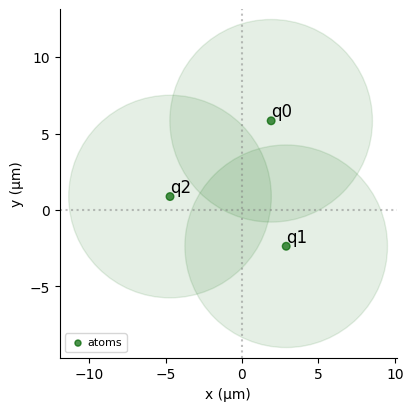

In [6]:
# ══════════════════════════════════════════════════════════════
# Resolucin clásica por fuerza bruta
# ══════════════════════════════════════════════════════════════
Q_exacta = np.array(Q_exacta)

bitstrings = [np.binary_repr(i, len(Q_exacta)) for i in range(2 ** len(Q_exacta))]
costs = []
# this takes exponential time with the dimension of the QUBO
for b in bitstrings:
    z = np.array(list(b), dtype=int)
    cost = z @ Q_exacta @ z
    costs.append(cost)
zipped = zip(bitstrings, costs)
sort_zipped = sorted(zipped, key=lambda x: x[1])
print(f"---Solución clásica: \n {sort_zipped[:6]} \n")



# ══════════════════════════════════════════════════════════════
# Paso QUBO a geometría
# ══════════════════════════════════════════════════════════════
# Simetrizar Q para el Nelder-Mead (la interacción C6/r^6 es simétrica)
#Q_sym = Q + Q.T - 2 * np.diag(np.diag(Q))  # diagonal = 0, off-diagonal simétricos
Q_sym = Q
device = pulser.DigitalAnalogDevice

def evaluate_mapping(
    new_coords: np.ndarray, Q: np.ndarray, device: pulser.devices.Device
):
    """Cost function to minimize. Ideally, the pairwise distances are conserved."""
    new_coords = np.reshape(new_coords, (len(Q), 2))
    # computing the matrix of the distances between all coordinate pairs
    new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
    return np.linalg.norm(new_Q - Q)

# Método Nelder-Mead: va tanteando la función de evaluación en diferentes coordenadas (formando triángulos y viendo entre medias) hasta ¡ encontrar un punto con tolerancia aceptable.  
costs = []
np.random.seed(0)
x0 = np.random.random(len(Q) * 2)
res = minimize(
    evaluate_mapping,
    x0,
    args=(Q_sym, device),
    method="Nelder-Mead",
    tol=1e-6,
    options={"maxiter": 200000, "maxfev": None},
)

coords = np.reshape(res.x, (len(Q_sym), 2))
print(f"Optimized coordinates: {coords}")

# Útil solo para visualización: Creamos el registro de Pulser (reg) con las coordenadas optimizadas.
coord_visualizacion_Pulser = {f"q{i}": coord for (i, coord) in enumerate(coords)}
reg = pulser.Register(coord_visualizacion_Pulser)
reg.draw(
    blockade_radius=device.rydberg_blockade_radius(1),
    draw_graph=False,
    draw_half_radius=True,
)


#### PASO A BLOQADE
coordenadas = [tuple(pt) for pt in coords.tolist()]
geometria = start.add_position(coordenadas)
geometria.show()


# Resolución con Pasqal
Sacado del tutorial: https://docs.pasqal.com/pulser/tutorials/qubo/ 

In [73]:
#sequence.declare_channel("rydberg_global", "rydberg_global")
#
## Convertir la lista de listas en un array de NumPy
#Q = np.array(Q)
#
## We choose a median value between the min and the max
#Omega = np.median(Q[Q > 0].flatten())
#delta_0 = -5  # just has to be negative
#delta_f = -delta_0  # just has to be positive
#T = 4000  # time in ns, we choose a time long enough to ensure the propagation of information in the system
#
#
#adiabatic_pulse = pulser.Pulse(
#    pulser.InterpolatedWaveform(T, [1e-9, Omega, 1e-9]),
#    pulser.InterpolatedWaveform(T, [delta_0, 0, delta_f]),
#    0,
#)
#sequence.add(adiabatic_pulse, "rydberg_global")
#sequence.draw()
#
#
#simul = pulser_simulation.QutipBackendV2(sequence)
#results = simul.run()
#count_dict = results.final_bitstrings
#
#
## Plot the distribution
#count_dict = dict(
#    sorted(count_dict.items(), key=lambda item: item[1], reverse=True)
#)
#indexes = ["01011", "00111"]  # QUBO solutions
#color_dict = {key: "r" if key in indexes else "g" for key in count_dict}
#plt.figure(figsize=(12, 6))
#plt.xlabel("bitstrings")
#plt.ylabel("counts")
#plt.bar(
#    count_dict.keys(),
#    count_dict.values(),
#    width=0.5,
#    color=color_dict.values(),
#)
#plt.xticks(rotation="vertical")
#plt.show()

# Resolución con Quera

-4704102.482600558 2894851.9008728787 -2368285.586966084 5838307.337985917


── PASO 5: Resultados ──
  Solución clásica:    ['001', '010', '100']  (E = -20.000)
  Conteos solución:    8096 / 10000
  Probabilidad éxito:  0.8096  (80.96%)


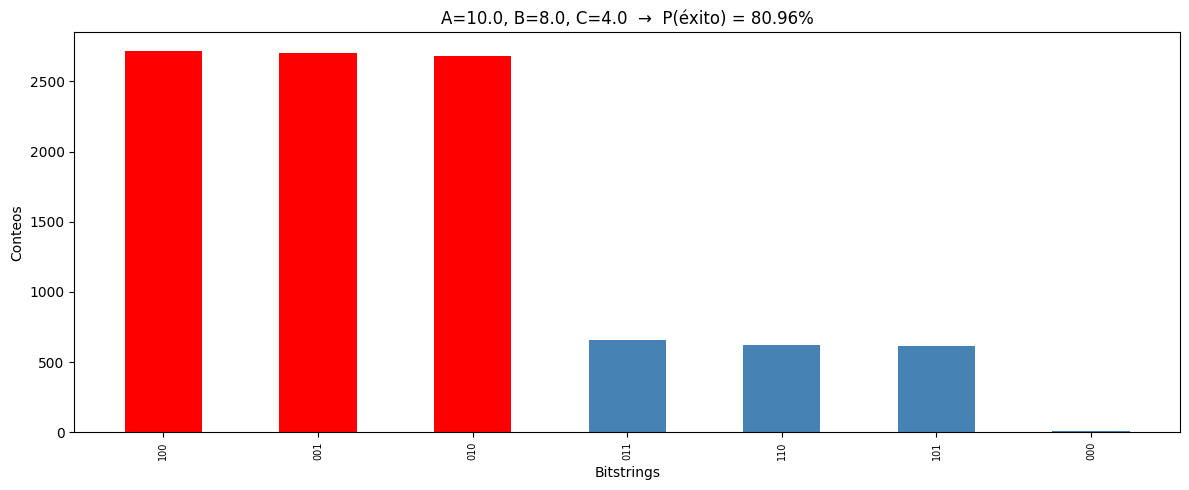

In [7]:
# ══════════════════════════════════════════════════════════════
# PASO 1: Extraer detunings locales desde la diagonal de Q
# ══════════════════════════════════════════════════════════════
# Δᵢ = -Qᵢᵢ (los términos diagonales codifican el detuning de cada átomo)
Q = np.array(Q)
delta_local = -np.diag(Q)
delta_end   = np.max(delta_local)
escalas     = (delta_local / delta_end).tolist()



# ══════════════════════════════════════════════════════════════
# PASO 2: Parámetros de simulación
# ══════════════════════════════════════════════════════════════
#omega_max  = 5    # Frecuencia de Rabi máxima [rad/µs]
#omega_max = 0.8*A
omega_max  = 0.3 * np.min(delta_local)
sweep_time = 11.0  # Tiempo de evolución adiabática [µs]


# ══════════════════════════════════════════════════════════════
# PASO 3: Montar programa Bloqade y ejecutar
# ══════════════════════════════════════════════════════════════
# Waveforms
durations             = [0.8, sweep_time, 0.8]
rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

# 'geometria' ya está definida en la celda anterior (Nelder-Mead)
n_shots = 10000

prog = (
    geometria
    .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
    .detuning.scale(escalas).piecewise_linear(durations, rabi_detuning_values)
)

emu_prog = prog.bloqade.python().run(shots=n_shots)
report   = emu_prog.report()
report.show()



# ══════════════════════════════════════════════════════════════
# PASO 4: Análisis de resultados y probabilidad de éxito
# ══════════════════════════════════════════════════════════════
# Extraer conteos del emulador
counts = report.counts()[0]  # dict {(0,1,0,...): n_apariciones, ...}

# Convertir a formato bitstring para comparar con la solución clásica
counts_str = {}
for estado, n in counts.items():
    bitstring = "".join(str(b) for b in estado)
    counts_str[bitstring] = n

# Solución clásica (ya calculada en la celda de fuerza bruta)
solucion_clasica = sort_zipped[0][0]  # bitstring óptimo
energia_minima   = sort_zipped[0][1]
# Incluir también soluciones degeneradas (misma energía)
soluciones_validas = [b for b, e in sort_zipped if e == energia_minima]

# Probabilidad de éxito
exitos = sum(counts_str.get(s, 0) for s in soluciones_validas)
prob_exito = exitos / n_shots

print("── PASO 5: Resultados ──")
print(f"  Solución clásica:    {soluciones_validas}  (E = {energia_minima:.3f})")
print(f"  Conteos solución:    {exitos} / {n_shots}")
print(f"  Probabilidad éxito:  {prob_exito:.4f}  ({prob_exito*100:.2f}%)")

# Histograma ordenado por conteos
counts_ordenado = dict(sorted(counts_str.items(), key=lambda x: x[1], reverse=True))
colores = ["r" if b in soluciones_validas else "steelblue" for b in counts_ordenado]

plt.figure(figsize=(12, 5))
plt.bar(counts_ordenado.keys(), counts_ordenado.values(), color=colores, width=0.5)
plt.xlabel("Bitstrings")
plt.ylabel("Conteos")
plt.title(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

# Función simulación

A=10.0, B=8.0, C=4.0  →  P(éxito) = 88.30%
  Soluciones válidas: ['001', '010', '100']  (E = -20.000)
  Conteos solución:   8830 / 10000


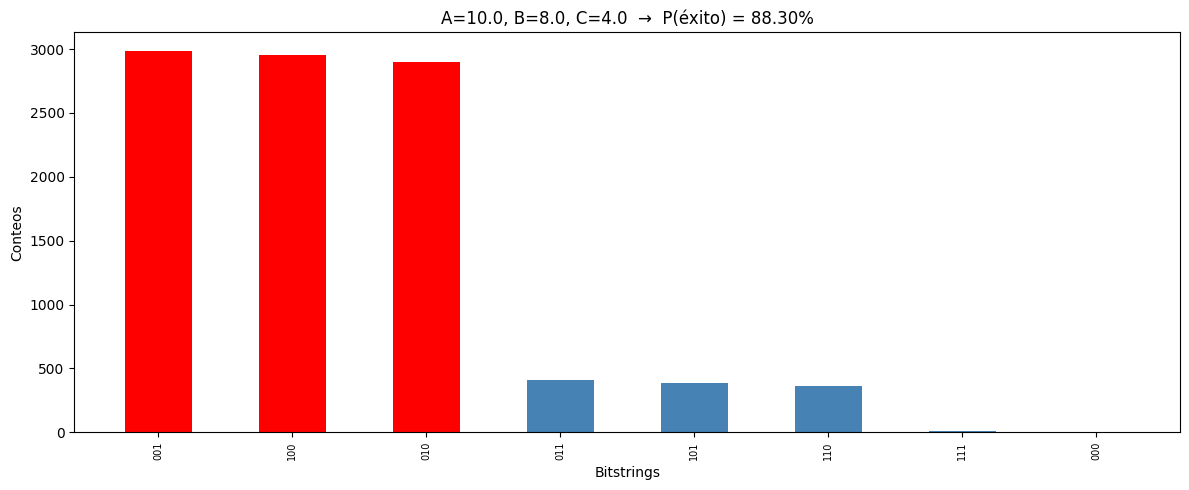

In [8]:
def resolver_qubo(Q, geometria, sort_zipped, A, B, C,
                   omega_max = 0.3*B, sweep_time=11.0, plot=True, n_shots=10000):
    """
    Ejecuta la simulación de átomos neutros para un problema QUBO dado.

    Parámetros
    ----------
    Q             : array-like  – Matriz QUBO.
    geometria     : Register     – Geometría de átomos (Bloqade).
    sort_zipped   : list[(str, float)] – Soluciones clásicas ordenadas (bitstring, energía).
    A, B, C       : float        – Coeficientes QUBO (solo para etiquetas).
    omega_max     : float        – Amplitud máxima de la frecuencia de Rabi.
    sweep_time    : float        – Tiempo de evolución adiabática [µs].
    plot          : bool         – Si True, muestra el histograma.
    n_shots       : int          – Número de disparos de la simulación.
    sweep_time    : float        – Tiempo de evolución adiabática [µs].
    plot          : bool         – Si True, muestra el histograma.

    Retorna
    -------
    prob_exito    : float        – Probabilidad de medir la solución correcta.
    counts_str    : dict         – {bitstring: conteos}.
    """
    # ── PASO 1: Detunings locales desde la diagonal de Q ──
    Q = np.array(Q)
    delta_local = -np.diag(Q)
    delta_end   = np.max(delta_local)
    escalas     = (delta_local / delta_end).tolist()

    # ── PASO 2: Parámetros de pulso ──
    #omega_max = 0.3 * np.min(delta_local)
    sweep_time=11.0
    durations             = [0.8, sweep_time, 0.8]
    rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
    rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

    # ── PASO 3: Simulación ──
    prog = (
        geometria
        .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
        .detuning.scale(escalas).piecewise_linear(durations, rabi_detuning_values)
    )
    emu_prog = prog.bloqade.python().run(shots=n_shots)
    report   = emu_prog.report()

    # ── PASO 4: Análisis ──
    counts = report.counts()[0]
    counts_str = {
        "".join(str(b) for b in estado): n
        for estado, n in counts.items()
    }

    energia_minima   = sort_zipped[0][1]
    soluciones_validas = [b for b, e in sort_zipped if e == energia_minima]

    exitos     = sum(counts_str.get(s, 0) for s in soluciones_validas)
    prob_exito = exitos / n_shots

    # ── PASO 5: Resultados ──
    print(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
    print(f"  Soluciones válidas: {soluciones_validas}  (E = {energia_minima:.3f})")
    print(f"  Conteos solución:   {exitos} / {n_shots}")

    if plot:
        counts_ordenado = dict(sorted(counts_str.items(), key=lambda x: x[1], reverse=True))
        colores = ["r" if b in soluciones_validas else "steelblue" for b in counts_ordenado]
        plt.figure(figsize=(12, 5))
        plt.bar(counts_ordenado.keys(), counts_ordenado.values(), color=colores, width=0.5)
        plt.xlabel("Bitstrings")
        plt.ylabel("Conteos")
        plt.title(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
        plt.xticks(rotation=90, fontsize=7)
        plt.tight_layout()
        plt.show()

    return prob_exito, counts_str




# Ejecución de la función 
prob, counts = resolver_qubo(Q, geometria, sort_zipped, A, B, C)

# Barrido resultados

In [72]:
A_values = [10.0]
B_values = [0.5*A, 0.8*A]
C_values = [0.5*B]
resultados = {}
for A in A_values:
    for B in B_values:
        for C in C_values:
            Q, sort_zipped = construir_qubo(A, B, C)  # tu código de construcción de Q
            prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False)
            resultados[(A, B, C)] = prob

NameError: name 'construir_qubo' is not defined

# Comprobaciones

In [69]:
# ══════════════════════════════════════════════════════════════
# PASO 1: Extraer detunings locales desde la diagonal de Q
# ══════════════════════════════════════════════════════════════
print("── PASO 1: Detunings locales ──")
for i, esc in enumerate(escalas):
    print(f"  Átomo {i}: Δ_{i} = {delta_local[i]:.3f} rad/µs  →  escala = {esc:.4f}")


# ══════════════════════════════════════════════════════════════
# PASO 2: Parámetros de simulación y comprobaciones
# ══════════════════════════════════════════════════════════════
C6 = 2 * np.pi * 862690  # Coeficiente de van der Waals [rad/µs · µm^6]
R_B = (C6 / omega_max) ** (1/6)
d = (C6 / A) ** (1/6)

delta_local_min = np.min(delta_local)
T_min_estimado  = 1 / omega_max**2

print("── PASO 2: Comprobaciones ──")
print(f"  Ω_max = {omega_max} rad/µs")
print(f"  R_B   = {R_B:.2f} µm")
print(f"  d = (C6/A)^(1/6) = {d:.2f} µm")ç

# Condición 1: Ω < A  (garantiza bloqueo de Rydberg)
if omega_max < A:
    print(f"  1. Ω={omega_max} < A={A} ✓  (bloqueo garantizado)")
else:
    display(HTML("<span style='color: #FF0000; font-weight: bold;'>"
                 "Condición 1 NO cumplida: Ω debe ser menor que A</span>"))

# Condición 2: Ω < min(Δᵢ)  (garantiza selectividad)
if omega_max < delta_local_min:
    print(f"  2. Ω={omega_max} < min(Δᵢ)={delta_local_min:.3f} ✓  (selectividad)")
else:
    display(HTML("<span style='color: #FF0000; font-weight: bold;'>"
                 "Condición 2 NO cumplida: Ω debe ser menor que min(Δᵢ)</span>"))

# Condición 3: T >> 1/Ω²  (adiabaticidad)
if sweep_time > 10 * T_min_estimado:
    print(f"  3. T={sweep_time} >> 1/Ω²={T_min_estimado:.4f} ✓  (adiabaticidad)")
else:
    display(HTML("<span style='color: #FF0000; font-weight: bold;'>"
                 "Condición 3 NO cumplida: sweep_time insuficiente</span>"))
    

# ══════════════════════════════════════════════════════════════
# PASO 3: Montar programa Bloqade y ejecutar
# ══════════════════════════════════════════════════════════════
print("── PASO 3: Ejecución ──")
print(f"  Átomos:  {len(Q)}")
print(f"  Shots:   {n_shots}")
print(f"  Tiempo:  {sum(durations):.1f} µs")


# ══════════════════════════════════════════════════════════════
# PASO 4: Análisis de resultados y probabilidad de éxito
# ══════════════════════════════════════════════════════════════
print("── PASO 5: Resultados ──")
print(f"  Solución clásica:    {soluciones_validas}  (E = {energia_minima:.3f})")
print(f"  Conteos solución:    {exitos} / {n_shots}")
print(f"  Probabilidad éxito:  {prob_exito:.4f}  ({prob_exito*100:.2f}%)")

SyntaxError: invalid syntax (1045561214.py, line 22)